# Project 1: Crop and Weed Detection
Author: Shrey Kandpal | Domain: Data Science & Machine Learning

IMPORTING ESSENTIAL LIBRARIES
AND INSTALL ULTRALYTICS

In [3]:
import os
import shutil
import random
import glob
import cv2
import matplotlib.pyplot as plt
from google.colab import drive

!pip install ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


CONNECTING GOOGLE DRIVE

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


COPYING DATASET TO FAST GOOGLE COLAB STORAGE

In [5]:
drive_data_path = "/content/drive/MyDrive/Machine Learning and Data Science Internship/Selected Projects/Project5_Ag_Crop and weed detection/Project5_Ag_Crop and weed detection/agri_data/data"
os.system(f'cp -r "{drive_data_path}" /content/raw_data')

images = glob.glob("/content/raw_data/*.jpeg")
labels = glob.glob("/content/raw_data/*.txt")
print(f"Verified: Found {len(images)} images and {len(labels)} label text files.")

Verified: Found 1300 images and 1300 label text files.


SPLITTING DATA INTO TRAIN/VALIDATION SETS & CREATE DATA.yaml

In [6]:
for split in ['train', 'val']:
    os.makedirs(f"/content/dataset/images/{split}", exist_ok=True)
    os.makedirs(f"/content/dataset/labels/{split}", exist_ok=True)

random.seed(42)
random.shuffle(images)

split_point = int(0.8 * len(images))
train_files = images[:split_point]
val_files = images[split_point:]

def copy_paired_files(file_list, split_name):
    for img_path in file_list:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        txt_path = f"/content/raw_data/{base_name}.txt"

        shutil.copy(img_path, f"/content/dataset/images/{split_name}/{os.path.basename(img_path)}")
        if os.path.exists(txt_path):
            shutil.copy(txt_path, f"/content/dataset/labels/{split_name}/{base_name}.txt")

copy_paired_files(train_files, 'train')
copy_paired_files(val_files, 'val')

yaml_content = """
path: /content/dataset
train: images/train
val: images/val

names:
  0: crop
  1: weed
"""
with open("/content/data.yaml", "w") as f:
    f.write(yaml_content.strip())

print(f"Data organized: {len(train_files)} training images, {len(val_files)} validation images.")

Data organized: 1040 training images, 260 validation images.


INSTALLING ULTRALYTICS AND TRAIN YOLOv8 NANO

In [7]:
model = YOLO("yolov8n.pt")
results = model.train(
    data="/content/data.yaml",
    epochs=15,
    imgsz=512,
    batch=16,
    plots=True
)
print("Training complete!")

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optim

TESTING THE MODEL QUANTITATIVELY (OVERALL ACCURACY ACROSS ALL 260 TEST IMAGES)

In [8]:
best_weights_path = os.path.join(results.save_dir, "weights", "best.pt") if hasattr(results, 'save_dir') else "/content/runs/detect/train/weights/best.pt"
trained_model = YOLO(best_weights_path)

metrics = trained_model.val()

print("             FINAL MODEL TEST METRICS                  ")
print("=======================================================")
print(f"Overall Precision:   {metrics.box.mp:.3f}")
print(f"Overall Recall:      {metrics.box.mr:.3f}")
print(f"Overall mAP@50:      {metrics.box.map50:.3f}")
print(f"Overall mAP@50-95:   {metrics.box.map:.3f}")

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2107.0±759.5 MB/s, size: 54.2 KB)
val: Scanning /content/dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 260/260 83.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 5.3it/s 3.2s
                   all        260        415      0.792      0.819      0.871       0.56
                  crop        123        241      0.752      0.817      0.862      0.566
                  weed        138        174      0.832      0.822       0.88      0.554
Speed: 1.4ms preprocess, 3.2ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
             FINAL MODEL TEST METRICS                  
Overall Precision:   0.792
Overall Recall:      

TESTING THE MODEL VISUALLY (SINGLE IMAGE TEST)


image 1/1 /content/dataset/images/val/agri_0_1171.jpeg: 512x512 1 crop, 5.8ms
Speed: 1.1ms preprocess, 5.8ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict


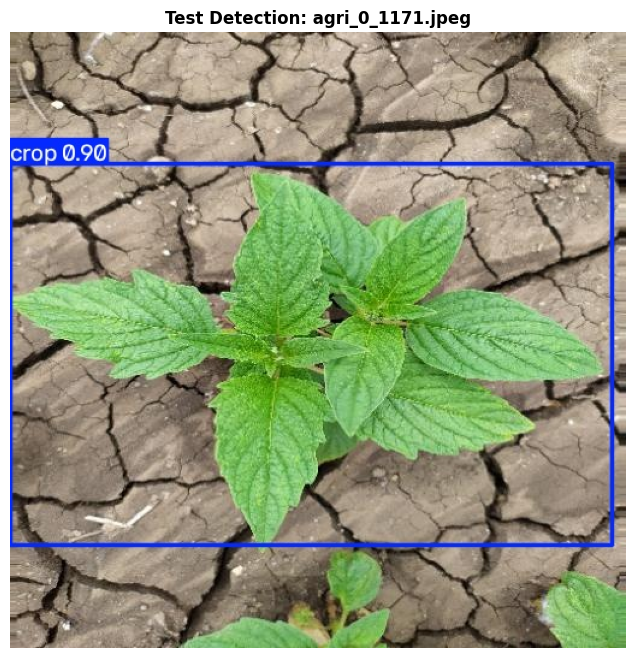


Detected 1 total objects in this image:
  • CROP with confidence: 90.25%


In [9]:
test_images = glob.glob("/content/dataset/images/val/*.jpeg")
if not test_images:
    print("Error: Images not found in the validation folder")
else:
    sample_test_image = test_images[0]
    prediction_results = trained_model.predict(source=sample_test_image, conf=0.25, save=True)

    save_directory = prediction_results[0].save_dir
    potential_images = glob.glob(os.path.join(save_directory, '*.jpeg')) + glob.glob(os.path.join(save_directory, '*.jpg'))

    if potential_images:
        annotated_img_path = potential_images[0]
        annotated_img = cv2.imread(annotated_img_path)

        if annotated_img is not None:
            annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(8, 8))
            plt.imshow(annotated_img_rgb)
            plt.axis('off')
            plt.title(f"Test Detection: {os.path.basename(sample_test_image)}", fontsize=12, fontweight='bold')
            plt.show()

            boxes = prediction_results[0].boxes
            print(f"\nDetected {len(boxes)} total objects in this image:")
            for box in boxes:
                class_id = int(box.cls[0])
                class_name = "crop" if class_id == 0 else ("weed" if class_id == 1 else f"unknown_class_{class_id}")
                confidence = float(box.conf[0])
                print(f"  • {class_name.upper()} with confidence: {confidence:.2%}")
        else:
            print(f"Error: cv2.imread returned None for {annotated_img_path}. Corrupt or Unreadable.")
    else:
        print(f"Error: Automated file not in Directory: {save_directory}")

TESTING THE MODEL ON A GRID OF 4 RANDOM TEST IMAGES


image 1/1 /content/dataset/images/val/agri_0_3613.jpeg: 512x512 2 crops, 7.5ms
Speed: 0.9ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/dataset/images/val/agri_0_8007.jpeg: 512x512 1 crop, 6.5ms
Speed: 0.7ms preprocess, 6.5ms inference, 2.8ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/dataset/images/val/agri_0_5529.jpeg: 512x512 1 weed, 5.9ms
Speed: 0.7ms preprocess, 5.9ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /content/dataset/images/val/agri_0_784.jpeg: 512x512 1 weed, 6.1ms
Speed: 0.6ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 512)


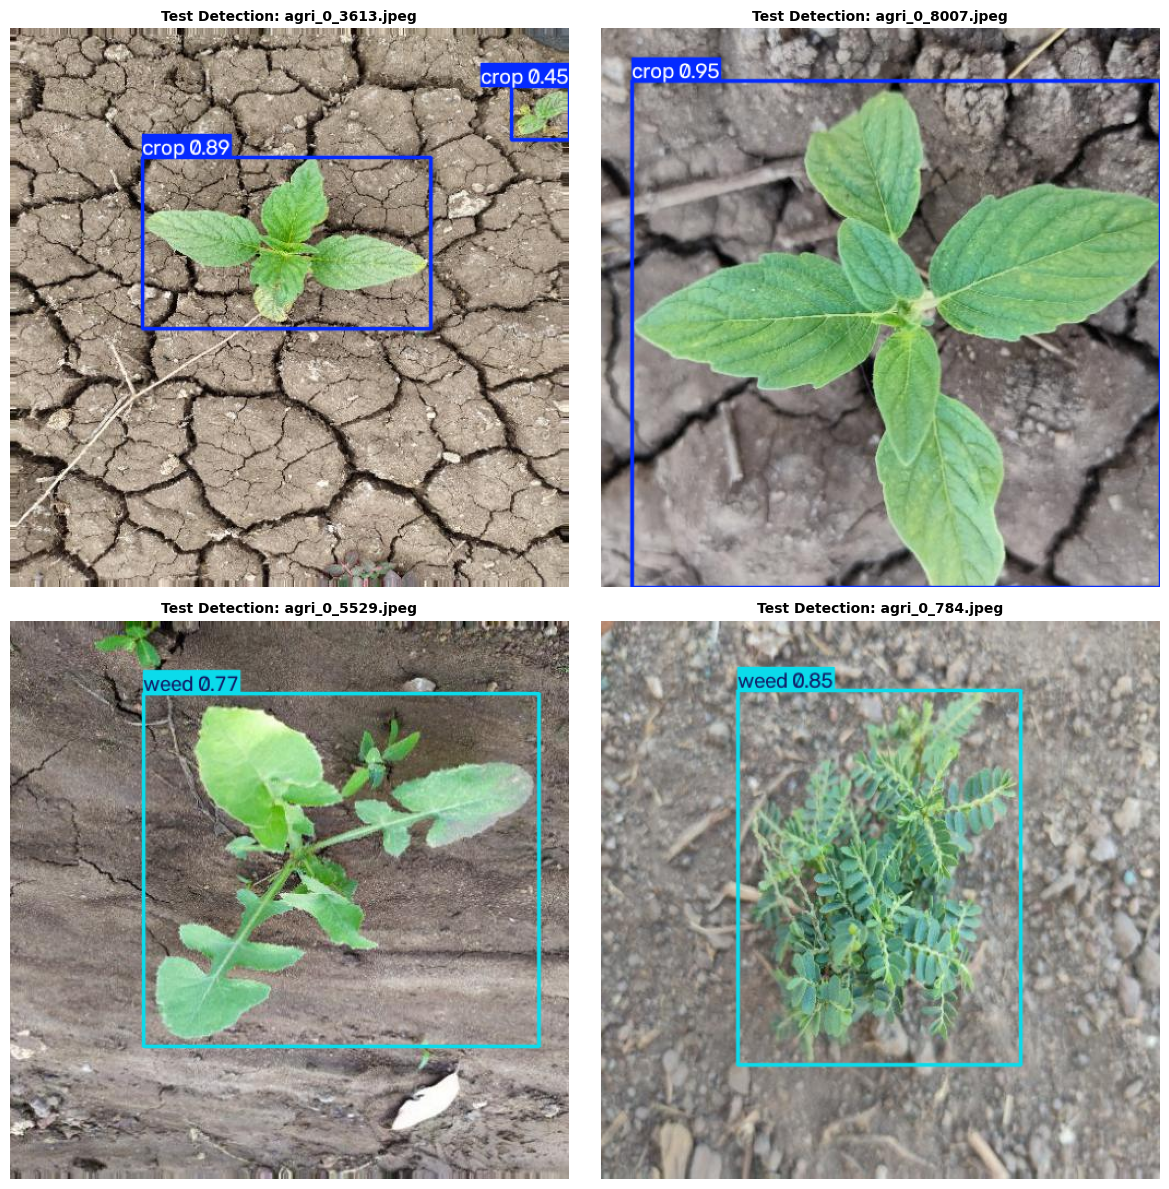

In [11]:
test_images = glob.glob("/content/dataset/images/val/*.jpeg")

if len(test_images) >= 4:
    # Pick 4 random images from the validation set
    sample_grid_images = random.sample(test_images, 4)

    plt.figure(figsize=(12, 12))

    for i, img_path in enumerate(sample_grid_images):
        # Run prediction in memory without saving to disk
        grid_result = trained_model.predict(source=img_path, conf=0.25)

        # Ultralytics .plot() returns a BGR numpy array with bounding boxes drawn
        annotated_bgr = grid_result[0].plot()
        annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

        # Add to 2x2 grid
        plt.subplot(2, 2, i + 1)
        plt.imshow(annotated_rgb)
        plt.axis('off')
        plt.title(f"Test Detection: {os.path.basename(img_path)}", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Error: Number of Images not enough for grid")